# ARGUS-FEDER — Answering GA's disruption competency questions

General Atomics maintains a set of 27 competency questions for DIII-D data,
split into an ELM half and a disruption half. This notebook works through the
**disruption half, Q14–Q27**, against a stored disruption index built from
`disruption-py` output.

Each question is tagged with what the indexes can actually deliver: answerable
now, answerable for one pipeline only, correctly refused, or — since a second
machine arrived — answerable on one machine and not the other.

## The one thing to keep in mind

GA's questions are written for **three** disruption pipelines. We have run
**one** — `disruption-py`, the public MIT-PSFC code. Questions that ask for
agreement *across* pipelines cannot be answered yet, and the correct response
is to say which pipeline was used and what is missing, not to answer as though
one pipeline were all of them.

The DIII-D index holds **20 shots, balanced 10 disrupted / 10 not**. It is a
demonstration slice, not a sample of the archive. Any question phrased as a
rate or a fraction is unanswerable from it by construction — and the same is
true of the C-Mod index below, which is the set of shots its provider
published times for rather than a sample of the machine.

## A second machine, the same pipeline

Since this notebook was first run, an **Alcator C-Mod** disruption index has
been added, built by the same `disruption-py` release. It is a second
*device*, not a second pipeline: questions that ask whether independent
pipelines agree remain as unanswerable as they were.

What it changes is that questions the DIII-D index could not answer are
answerable on C-Mod. Where one machine answers and the other does not, the gap
is itself the finding.


In [ ]:
%reset

---
# A. Answerable now, from this index

## Q20 — Which pipeline produced a label, at what version, from which inputs?

_provenance · **answerable**_

Provenance is answerable by construction once a pipeline is run and what was
run is recorded alongside the labels it produced.

In [2]:
%%ask --review
For the disruption labels in the index: which code produced them, at what
version and commit, when was it run and by whom, and what were its inputs? Show
me the full provenance record.

I'll start by planning this provenance lookup, then read the relevant skill documentation.

Reading the disruption skill instructions plus its existing learnings file in parallel.

The skill documents `index_info()` as the provenance call, and the Learnings file flags an expired-token trap. Writing a query script that applies the learned fix.

Now running the script to fetch the provenance record from the index.

The provenance record is in. Since the question is specifically about the *labels*, I'll also document the two label sources and where they disagree.

Running the label-sources script to capture the label lineage alongside the code provenance.

**Full provenance record for the disruption index** (from `index_info()`, which reads it straight from the source file's global attributes):

**Producing code**
- **Package** : `disruption_py` (the MIT-PSFC disruption-py pipeline)
- **Version** : `0.15.0.dev0`
- **Commit** : `9987784e78ef9736e2fe42142683b3458ff38d8d`
- **Source repo** : https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d
- **Tokamak** : D3D

**Run details**
- **Run by** : `sammuli`
- **Run on** : `omega06.gat.com`
- **Produced at** : 2026-08-19T07:36:50.648611 (no timezone in the file's attribute; naive timestamp)
- **Source file produced** : `d3d_disruption_example.nc`
- **Ingested into this index** : 2026-08-19T20:46:49+00:00 (run_id 1)

**Inputs**
- The pipeline's inputs are DIII-D shot data for the slice covered: shots **194000–199687** , of which **20 shots** were ingested (10 disrupted, 3778 sample rows).
- For the labels themselves, provenance splits into two distinct inputs:
  1. **The label** — `time_until_disrupt`, taken from the **human-curated `disruptions` table in d3drdb** (the DIII-D relational database). This is the authoritative label `disruption_label()` returns.
  2. **A derived indicator, not the label** — `current_quench_time`, disruption-py's own estimate from the Ip decay at commit `9987784...`. It **disagrees with the curated label on 3 of the 20 shots** (198244, 198643, 199062 — all curated-as-not-disrupted but Ip-decay-flagged), so the two are kept deliberately separate.

**Caveats worth carrying with this record**
- The 20-shot set is a **constructed slice, not a random sample** of DIII-D (`is_representative_sample: False`) — it was chosen to span a range of behaviour with a deliberate 10/10 disrupted/non-disrupted split. No archive-wide disruption rate can be computed from it.
- The parameter list and the known parameter defects are properties of this specific revision (`0.15.0.dev0` @ `9987784`); a re-ingest from a newer disruption-py would change both.

The query scripts are saved as `provenance_query.py` and `label_sources.py` in the working directory.

## Q15 — Which quantities are disruption precursors, and what measures each?

_precursor map · **answerable**_

The assessment noted that `disruption-py`'s feature set *is* the precursor
map — n=1 mode amplitude, betap, li, q95, radiated fraction, locked mode,
v_loop. Now that it has been run, that map is queryable with units attached.

In [3]:
%%ask --review
Which quantities in this dataset are disruption precursors, and what does
each one measure? Group them by the physics method that produces them, and give
the units for each.

Reading the helper module to confirm the exact function signatures and return shapes.

Skill and learnings read — the token-env fix from Learnings goes at the top of my script. Now querying the parameter dictionary grouped by method.

All 63 parameters retrieved with their method groups, descriptions, units, and caveats. Now I can classify the precursor set versus the label layer.

The 63 columns in this index split into two layers: **60 physics quantities** (the precursor candidates a warning system would consume) and **3 label/phase columns** that describe the shot's outcome, not its state. Everything below is read from the index's own parameter dictionary (`parameters()` / `parameter_info()`), produced by disruption-py `0.15.0.dev0` @ `9987784e78ef9736e2fe42142683b3458ff38d8d` — the parameter list and its defects are properties of that revision.

Units convention: `1` means genuinely dimensionless; `instrument` (h_alpha) means uncalibrated detector units, not SI.

## Precursor quantities, grouped by producing physics method

**Equilibrium reconstruction — `get_efit_parameters`** (filled only where EFIT converged; gaps concentrate at shot end, 84.6% fill)

| Parameter | Measures | Units |
|---|---|---|
| q95 | Safety factor at 95% flux surface — distance from the low-q kink/tearing boundary (disruptive limit: approaching 2 from above) | 1 |
| q0 | Safety factor on axis | 1 |
| qstar | Cylindrical safety factor | 1 |
| wmhd | Stored magnetic energy — confinement quality | J |
| dwmhd_dt | Rate of change of stored energy | W |
| beta_n | Normalised beta | % m T MA⁻¹ |
| beta_p | Poloidal beta — normalized plasma pressure | 1 |
| dbetap_dt | Rate of change of poloidal beta | s⁻¹ |
| li | Internal inductance — current-profile peaking | 1 |
| dli_dt | Rate of change of internal inductance | s⁻¹ |
| kappa | Elongation | 1 |
| chisq | EFIT fit quality (reconstruction reliability) | 1 |
| upper_gap / lower_gap | Plasma-to-wall gap, top / bottom — proximity of the plasma to limiting surfaces | m |

**MHD modes — `get_n1_bradial_parameters` / `get_n1rms_parameters`** (98.8–100% fill)

| Parameter | Measures | Units |
|---|---|---|
| n1rms | n=1 RMS magnetic amplitude — locked/unstable mode growth, the classic locked-mode precursor | T |
| n1rms_normalized | n=1 RMS normalised by toroidal field | 1 |
| n_equal_1_mode | n=1 radial field amplitude | T |
| n_equal_1_normalized | n=1 amplitude normalised by toroidal field | 1 |

**Density — `get_density_parameters`** (line-averaged density)

| Parameter | Measures | Units |
|---|---|---|
| n_e | Line-averaged electron density | m⁻³ |
| greenwald_fraction | n_e against the Greenwald density limit — the density-limit disruption metric | 1 |
| dn_dt | Rate of change of density | m⁻³ s⁻¹ |

**Plasma current — `get_ip_parameters`**

| Parameter | Measures | Units |
|---|---|---|
| ip | Measured plasma current — its decay is the current quench | A |
| dip_dt | Rate of change of plasma current | A s⁻¹ |
| ip_prog | Programmed (commanded) plasma current — reference for tracking | MA |

**Ohmic drive — `get_ohmic_parameters`**

| Parameter | Measures | Units |
|---|---|---|
| v_loop | Loop voltage — resistive state of the plasma | V |
| p_ohm | Ohmic heating power | W |

**Heating and radiation — `get_power_parameters`**

| Parameter | Measures | Units |
|---|---|---|
| p_rad | Radiated power (bolometry, causal 10 ms smoothing) — radiative-collapse precursor | W |
| radiated_fraction | p_rad / total input power — impurity/dilution indicator | 1 |
| p_nbi | Neutral-beam injected power | W |
| p_ech | Electron-cyclotron heating power | W |

**Profile peaking, real-time — `get_peaking_factors`** (core-vs-all and divertor asymmetries; precursor to core radiative collapse and divertor detachment)

| Parameter | Measures | Units |
|---|---|---|
| prad_peaking_cva_rt | Radiated-power peaking, core vs. all | 1 |
| prad_peaking_xdiv_rt | Radiated-power peaking, divertor region | 1 |
| ne_peaking_cva_rt | Density peaking, core vs. all | 1 |
| te_peaking_cva_rt | Temperature peaking, core vs. all | 1 |

**Real-time twins** — a parallel measurement path computed by the plasma-control system rather than offline analysis, one per group above:

| Method | Parameters | Units |
|---|---|---|
| get_rt_efit_parameters (real-time equilibrium) | q95_rt, wmhd_rt, beta_p_rt, li_rt, chisq_rt | 1, J, 1, 1, 1 |
| get_rt_ip_parameters (real-time current) | ip_rt, ip_prog_rt, dip_dt_rt, dipprog_dt_rt | A, A, A s⁻¹, A s⁻¹ |
| get_rt_density_parameters (real-time density) | n_e_rt, greenwald_fraction_rt, dn_dt_rt | m⁻³, 1, m⁻³ s⁻¹ |

**Vertical position — `get_z_parameters`** (vertical-displacement-event precursor)

| Parameter | Measures | Units |
|---|---|---|
| zcur | Vertical position of the current centroid | m |
| zcur_normalized | zcur normalised by minor radius | 1 |

**Geometry — `get_shape_parameters` / `get_kappa_area`**

| Parameter | Measures | Units |
|---|---|---|
| aminor | Minor radius | m |
| delta | Triangularity (mean of top and bottom) | 1 |
| kappa_area | Elongation from cross-sectional area | 1 |
| squareness | Squareness | 1 |

**Mixed singles** (`get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed`)

| Parameter | Measures | Units |
|---|---|---|
| h98 | H98(y,2) confinement quality factor — degradation is a slow precursor | 1 |
| z_eff | Effective ion charge — impurity content/dilution | 1 |
| h_alpha | H-alpha line emission (uncalibrated) — recycling/edge behaviour | instrument |
| btor | Toroidal magnetic field | T |
| power_supply_railed | E-coil supplies at their limit — Ip feedback authority lost (0/1 flag) | 0 / 1 |

## Label layer — not precursors

| Column | Role | Units |
|---|---|---|
| time_until_disrupt | The label: seconds remaining until disruption (NaN for non-disrupted shots), from the curated d3drdb table | s |
| current_quench_time | Derived indicator: Ip-decay-estimated quench time — disagrees with the label on 3 of 20 shots | s |

## Columns you cannot use (3 of 63)

- **ip_error** — numerically identical to `ip` (the MA-vs-A mismatch makes the subtraction a no-op).
- **dipprog_dt** — MA s⁻¹ while its real-time twin is A s⁻¹; use `dipprog_dt_rt`.
- **time_domain** — constant 1.0 everywhere (flat-top test never fires); carries no information.

Two further cautions from the dictionary: **ip_error_rt** is marked usable but carries a ~205× constant gain (compute `ip_rt − ip_prog_rt` instead), and **radiated_fraction** needs clipping. `ip_prog` is in MA, not A — scale it before differencing against `ip`.

The query script is saved as `precursor_inventory.py` in the working directory.

## Q19 — For a given shot, what is the label and the time, and do the indicators agree?

_label agreement · **partially answerable**_

GA asks whether three pipelines agree. We have one — but that one carries **two
independent disruption indicators**, and they disagree on some shots.

In [4]:
%%ask --review
For DIII-D shot 194128, give me the disruption label and the disruption
time. Then tell me whether the dataset contains more than one disruption
indicator, whether they agree, and on which shots they disagree.

I'll consult the d3d-disruption skill (and its Learnings.md, which exists for this skill) before writing the query.

Reading the skill instructions and its learned-error notes.

Applying the learned token fix, I'll write a script that queries the label for 194128 both ways plus the disagreement list.

Running the label query script.

Both queries returned cleanly — marking the work complete and reporting.

## Shot 194128

- **Disruption label** : **disrupted** (per the authoritative curated label)
- **Disruption time (t_disrupt)** : **5.6267 s** (5.626669406890869)

**Coverage note** : the index stops AT the disruption — the last sample for this shot sits at t_disrupt = 5.6267 s exactly, and neither the thermal quench (~0.1–1 ms) nor the current quench (~1–10 ms) is inside this data.

## More than one disruption indicator? Yes — two

| Indicator | Source | 194128 disrupted? | 194128 t_disrupt |
|---|---|---|---|
| `time_until_disrupt` | Human-curated `disruptions` table in d3drdb — **this is the label** | True | 5.626669… s |
| `current_quench_time` | disruption-py's own estimate from the Ip decay — derived indicator, not the label | True | 5.626669… s |

The two are deliberately kept separate in the interface: `disruption_label()` returns the curated one by default, and the derived one requires `derived=True`, so the disrupted count cannot shift silently between definitions.

## Do they agree?

**Yes on shot 194128** — both flag it disrupted at the identical time, 5.6267 s (the index's `t_disrupt` for this shot is a single value; both indicators resolve to it here).

**Across the index: agreement on 17 of 20 shots; disagreement on 3.** The index covers 20 shots (10 curated-disrupted, 10 not — a deliberately balanced constructed slice, not a random sample of DIII-D). On all 3 disagreement shots the pattern is the same direction: the curated table says **not disrupted** , but the Ip-decay estimate says **disrupted** :

| Shot | Curated label | Derived (Ip decay) |
|---|---|---|
| 198244 | not disrupted | disrupted |
| 198643 | not disrupted | disrupted |
| 199062 | not disrupted | disrupted |

**Which to use** : the curated d3drdb label. The Ip-decay-derived indicator is disruption-py's own estimate at commit `9987784e78ef9736e2fe42142683b3458ff38d8d` (v0.15.0.dev0) and is known to disagree with the curated table on exactly these minority of shots — likely a normal ramp-down Ip decay being flagged as a quench, though the index does not record the reason.

The query script is saved as `shot_194128_labels.py` in the working directory.

---
# B. Answerable for one pipeline only

## Q14 — What definition of "disruption" does the pipeline implement?

_definition · **one of three pipelines**_

In [5]:
%%ask --review
What definition of a disruption, and of the disruption time, does the
pipeline behind these labels use? Where is that definition documented, and how
would I check it? Be clear about which pipeline this is and which ones are
missing.

The question is about the label-generating pipeline's definition of disruption, so I'll start by planning, then go back to the skill's documentation.

Reading the skill's full documentation to locate the definition of the disruption label.

The SKILL.md describes the two label columns but doesn't state the formal definition. Checking the skill's reference files and learnings.

The learnings flag a token-shadowing issue to pre-empt. Now querying the index for the label columns' full annotations and the provenance record.

Running the query script to pull the label annotations verbatim.

...

Writing a script that probes the pinned commit on GitHub for the label-defining code and lists the d3drdb snapshot's tables.

Running the probe to confirm what's documented and checkable at the pinned commit and in the local snapshot.

The snapshot carries only 5 tables — no curated disruptions table locally. One quick check whether the pinned commit URL resolves on GitHub before writing the report.

Both checks are done — the repo resolves but the pinned commit does not, and the local snapshot lacks the curated table. Closing out the plan and reporting.

## Which pipeline produced these labels

There are two, and the split matters because only one of them actually *defines* the disruption:

1. **disruption-py** (MIT-PSFC), version `0.15.0.dev0`, commit `9987784e78ef9736e2fe42142683b3458ff38d8d`, run by `sammuli` on `omega06.gat.com` on 2026-08-19 — this is the pipeline that produced the NetCDF this index ingests. It computed all 60 physics columns **and one derived disruption indicator** , but it did not decide which shots disrupted.
2. **The human-curated disruption table maintained in DIII-D's shot database (d3drdb)** — this is where the label actually comes from. disruption-py read it and repackaged it as `time_until_disrupt`.

## The definition

**"Disrupted"** — a shot is disrupted if it appears in that human-curated table. This is an *operational* definition: the criterion is whatever the DIII-D operators/analysts who maintain the table applied when they entered the row. **No machine-readable criterion — no Ip threshold, no locked-mode condition, no radiated-fraction cut — is recorded anywhere in this index.** The index's own annotation for the label column says only:

> `time_until_disrupt` — "Seconds remaining until disruption; NaN if the shot did not disrupt" (units s, authoritative)

**"Disruption time"** — `t_disrupt` is the time recorded in that curated table; `time_until_disrupt` is `t_disrupt − t` computed per sample, NaN for non-disrupted shots. The index's samples stop exactly at `t_disrupt`, so the thermal and current quenches (ms-scale, after that instant) are outside the data.

**The derived indicator, for contrast** — `current_quench_time` is disruption-py's own estimate ("Ip-decay-derived quench time", units s, non-authoritative, caveat: "disagrees with the label"). Whatever Ip-decay criterion it applies is implemented in disruption-py's DIII-D method code at the pinned commit — not in this index. It disagrees with the curated label on 3 of the 20 shots (198244, 198643, 199062 — all curated-as-clean, flagged by Ip decay).

## Where the definition is documented

- **In this index** : the parameter annotation layer (`parameter_info('time_until_disrupt')` / `parameter_info('current_quench_time')`) and `disruption_label()`, which reports its source as *"time_until_disrupt (d3drdb, curated)"*. That is the complete machine-readable record — the `method_desc` field for the label group is an **empty string** .
- **In disruption-py** : the Ip-decay logic for `current_quench_time` lives in the DIII-D method modules at commit `9987784…`. I probed the pinned URL recorded in the provenance (`https://github.com/MIT-PSFC/disruption-py/tree/9987784…`) and **the commit no longer resolves on GitHub (HTTP 422) — the repo itself is live, default branch `dev`, but this revision is not currently readable there.** So I cannot quote that code, and you should not treat my description of it as more than the index's one-line annotation.
- **Nowhere accessible here** : the curated table's own entry criteria.

## How you would check it, and what is missing

What you *can* verify in this environment:
- `disruption_label(shot)` — the label and its stated source, per shot.
- `disruption_label(shot, derived=True)` and `label_disagreements()` — the derived indicator and exactly where the two definitions diverge.
- `index_info()` — the pinned commit and run metadata, so any re-derived answer can be tied to a revision.

What is **missing** , plainly:
- **The curated disruption table itself is not in the d3drdb snapshot served here.** I listed its tables: shot records, shot types, signal catalog (2 tables), and shot-summary scalars only. The two dedicated disruption tables were deliberately excluded as legacy, and the summary table's `t_disrupt`-like column is explicitly not a verified label source. So the label's ground truth cannot be independently re-checked in this environment — the index is the only carrier of it.
- **The curators' criterion** — not recorded in any of these systems.
- **The Ip-decay threshold in disruption-py** — lives in source at a commit that currently 422s on GitHub; retrievable only if that revision resurfaces (e.g. a fork or a local clone pinned to `9987784…`).

Bottom line: the label means "the DIII-D curated disruption table says so, at that time," full stop. If your work depends on the precise physical criterion, that has to come from GA's disruption-pipeline documentation or the disruption-py source at the pinned commit — neither is reachable from here today, and the honest position is that the index's one-line annotations are the entire local record.

The check scripts are saved as `definition_labels.py`, `definition_pipeline_check.py`, and `definition_commit_probe.py` in the working directory.

## Q22 — Which shots have every input the pipeline requires?

_input availability · **partially answerable**_

In [6]:
%%ask --review
Which parameters does this pipeline produce, and how completely are they
populated across the shots in the index? Identify any parameters that are
missing for a substantial fraction of rows, and say which shots are affected.

I'll start by re-reading the skill documentation and its learned pitfalls, then plan the completeness audit.

Now I'll read the skill's learned-error record to avoid past pitfalls.

The skill documents the exact workflow for this (fill_pct index-wide, per-shot counting, None-handling trap), and the learnings file flags a token pitfall to pre-empt. Planning the audit now.

Inventory complete: 63 columns, 37 below 95% index-wide fill. Now counting per-shot coverage for the sparse groups to identify affected shots.

The per-shot matrix reveals clean patterns (z_eff is all-or-nothing per shot; squareness tracks EFIT where present). One more probe: confirm the 100%-fill columns, verify gap placement at shot tails, and finalize zero-coverage lists.

All three audit scripts ran clean. Marking the plan complete and reporting.

## Parameter inventory and completeness audit

All numbers below come from the index's own annotation layer and direct row counts, at disruption-py `0.15.0.dev0` @ commit `9987784e78ef9736e2fe42142683b3458ff38d8d`. The index holds **63 columns** (including 3 blocked as unusable, marked below) over **3778 rows / 20 shots** (10 disrupted; shots 194000–199687 — a constructed slice, so these fractions describe the slice only). Of the 63, **37 sit below 95% index-wide fill** ; the rest are essentially complete.

### The full parameter list, by producing method, with index-wide fill

| Method (disruption-py) | Parameters | Fill |
|---|---|---|
| get_ip_parameters (5) | ip, ip_prog, dip_dt | 100% |
| get_ip_parameters (blocked) | dipprog_dt; ip_error (94.5%) | 100% / 94.5% |
| get_rt_ip_parameters (5) | ip_rt, ip_prog_rt, dip_dt_rt, dipprog_dt_rt | 100% |
| get_rt_ip_parameters | ip_error_rt | 94.5% |
| get_ohmic_parameters (2) | v_loop | 100% |
| get_ohmic_parameters | p_ohm | 84.6% |
| get_power_parameters (4) | p_nbi, p_ech, p_rad | 100% |
| get_power_parameters | radiated_fraction | 84.6% |
| get_peaking_factors (4) | prad_peaking_cva_rt, prad_peaking_xdiv_rt | 100% |
| get_peaking_factors | ne_peaking_cva_rt, te_peaking_cva_rt | 73.2% |
| get_btor / get_h_alpha / get_h98 / get_zeff_parameters / get_power_supply_railed (5) | btor, h_alpha, power_supply_railed | 100% |
| same group | h98 | 73.7% |
| same group | z_eff | 51.2% |
| get_z_parameters (2) | zcur | 100% |
| get_z_parameters | zcur_normalized | 84.6% |
| get_n1_bradial / get_n1rms (4) | n_equal_1_mode, n_equal_1_normalized | 100% |
| same group | n1rms, n1rms_normalized | 98.8% |
| get_density_parameters (3) | n_e, greenwald_fraction, dn_dt | 94.0% |
| get_rt_density_parameters (3) | n_e_rt, dn_dt_rt | 100% |
| get_rt_density_parameters | greenwald_fraction_rt | 99.9% |
| get_rt_efit_parameters (5) | q95_rt, wmhd_rt, beta_p_rt, li_rt, chisq_rt | 94.2% |
| get_efit_parameters (14) | q95, q0, qstar, wmhd, kappa, chisq, beta_n, beta_p, li, upper_gap, lower_gap | 84.6% |
| get_efit_parameters (derivatives) | dwmhd_dt, dbetap_dt, dli_dt | 82.5% |
| get_shape_parameters / get_kappa_area (4) | aminor, delta, kappa_area | 84.6% |
| same group | squareness | 70.9% |
| Labels and shot phase (3) | time_until_disrupt | 48.8% |
| same group | current_quench_time | 66.4% |
| same group (blocked) | time_domain | 100% |

That enumeration is all 63. Three are blocked regardless of fill (`ip_error`, `dipprog_dt`, `time_domain` — the MA/A unit-defect family); `fetch_samples()` raises on them because they return plausible-but-wrong numbers. The two label columns' shortfalls are **by design** : `time_until_disrupt` is NaN exactly on non-disrupted rows (1845 of 3778 = its 48.8% fill), and `current_quench_time` is filled only where disruption-py's Ip-decay estimator produced a value. I verified the "100%" columns per shot: every one checked is ≥99.6% on its worst shot, so those are genuinely complete.

### Parameters with substantial gaps, and the shots affected

**z_eff — 51.2%, all-or-nothing per shot.** Entirely absent (0 rows) on **10 of 20 shots** : 194000, 194005, 194128, 194292, 194464, 194649, 194968, 195805, 196273, 198244; 100% filled on the other ten. No partial coverage anywhere — the diagnostic either ran for the shot or didn't.

**h98 — 73.7%.** Zero on **4 shots** (194649, 194869, 195985, 198643) and partial on six more, spanning **55.4–88.3%** (195516 lowest at 55.4%; 194464 highest at 88.3%; the others: 194000 at 74.0%, 194968 at 79.5%, 195243 at 71.1%, 195768 at 83.5%). The partial gaps sit late in each discharge.

**ne/te peaking factors — 73.2%.** The pair is zero together on **4 shots** : 194000 (a disrupted shot, t_disrupt 0.8296 s) plus 195805, 196273 and 198244 (non-disrupted) — so three of the four zero-coverage shots are non-disrupted. Partial on 194464, 194869, 194968, 195243, 195516, 195768. The prad peaking twins, by contrast, are 100% filled.

**squareness — 70.9%.** Zero on the **6 shots with the worst EFIT coverage** (194000, 194005, 194128, 194292, 194464, 195516) and partial wherever EFIT is partial — it tracks the EFIT convergence pattern.

**The EFIT block (14 columns + shape/zcur_normalized/p_ohm/radiated_fraction) — 82.5–84.6%.** This is the largest structurally-linked gap. Per-shot q95 coverage: **194464 is the disaster case at 5.8% overall and 0/55 rows in its last 200 ms** ; 195516 (55.4%), 194292 (53.9%), 194128 (73.6%), 194005 (77.1%), 195243 (77.8%), 194000 (67.5%), 194869 (82.9%), 194968 (86.4%), 195768 (83.5%) are all below 90%. No shot has zero EFIT coverage. Critically, **the gaps concentrate at the shot tail — exactly the pre-disruption window** : last-200-ms fill is 0% on 194869 and 195243, 27% on 195516, 29% on 195768, 42% on 194292 (only 194128, at 92.7%, keeps its tail).

**RT-EFIT (94.2%) is the mirror image** : far better filled than offline EFIT everywhere except **194869, where it is entirely zero** (0 rows) while offline EFIT has 82.9% — on that one shot the two measurement paths swap roles. Also below 90% on 194000 (79.2%), 195516 (80.4%), 194968 (87.5%).

**Density (94.0%)** : below 90% on 194000, 194464, 194869, 194968, 195243, 195516 (worst 55.4%). **n1rms (98.8%)** dips on exactly one shot: 198643 (78.1%).

### Practical summary

- For pre-disruption work, **count EFIT columns in your specific window, not index-wide** — 10 of 20 shots lose EFIT coverage exactly in the final 200 ms.
- The most reliable late-shot columns are the current/power/MHD set (ip, dip_dt, v_loop, p_rad, p_nbi, p_ech, h_alpha, btor, n_equal_1_*, the `_rt` current columns, n_e_rt and dn_dt_rt at 100%, prad peaking) — the verified ones are ≥99.6% on every shot, with greenwald_fraction_rt close behind at 99.9% index-wide.
- z_eff cannot support any cross-shot comparison: half the slice simply has none.
- Shot **194464** is the least-covered shot overall (EFIT 5.8%, tail 0%); **194869** is the mirror case (RT-EFIT absent entirely).

The audit scripts are saved as `completeness_inventory.py`, `completeness_by_shot.py`, and `completeness_zero_coverage.py` in the working directory.

## Q25 — Can a hazard-model dataset be assembled?

_survival analysis · **assemblable for C-Mod, still short for DIII-D**_

A hazard model needs two times per shot: when it entered flat-top, and when it
disrupted or ended without disrupting. The second has always been available.
The first was the open question, and on one of the two machines it no longer
is. Survival analysis also needs the discharges that did *not* disrupt — the
censored observations — so what matters is not only whether the times exist,
but whether both outcomes are represented.

Now the d3d learnings and the C-Mod skill (which is in the learnings list too).

Both skills and learnings are loaded. Key facts: DIII-D has **no native phase/flat-top column that works** (`time_domain` is blocked — constant 1.0 from the ip_prog MA/A defect), so flat-top entry must be derived from `ip`; C-Mod has a native `flattop_entry()` call purpose-built for hazard models. Updating the plan accordingly.

Writing the DIII-D hazard-coverage script: it confirms the phase-column situation, then derives flat-top entry from `ip` with the hysteresis anchor and pairs it with each shot's event/censoring time.

The row key is `caveat`, not `reason` — fixing the print, then recording the lesson per protocol.

Lesson recorded. Re-running the fixed DIII-D script.

...

Everything reconciles now: **438 shots = 156 events + 282 censored** (censored is exactly `not disrupted` on every row; my earlier `censored=10` print was the anomaly, contradicted by its own later lines). And the 18 no-flat-top shots decompose cleanly: 15 disrupted with phase-1 running to the event (delta ≈ 0), 1 disrupted with no phase data (931008014), 2 non-disrupted that only ever saw phase 1. Now the figure and verified CSVs.

`Line2D` needs both positional data args — fixing the legend proxies.

Lesson recorded. Re-running the figure script after the Line2D fix.

Both sides reconcile. Marking the plan complete and reporting.

## Short answer

**C-Mod: yes, natively — both times, in one call. DIII-D: half natively** — the disruption/censoring time is native, the flat-top entry is not, because the index's only phase column is defective; I derived it from the plasma current instead.


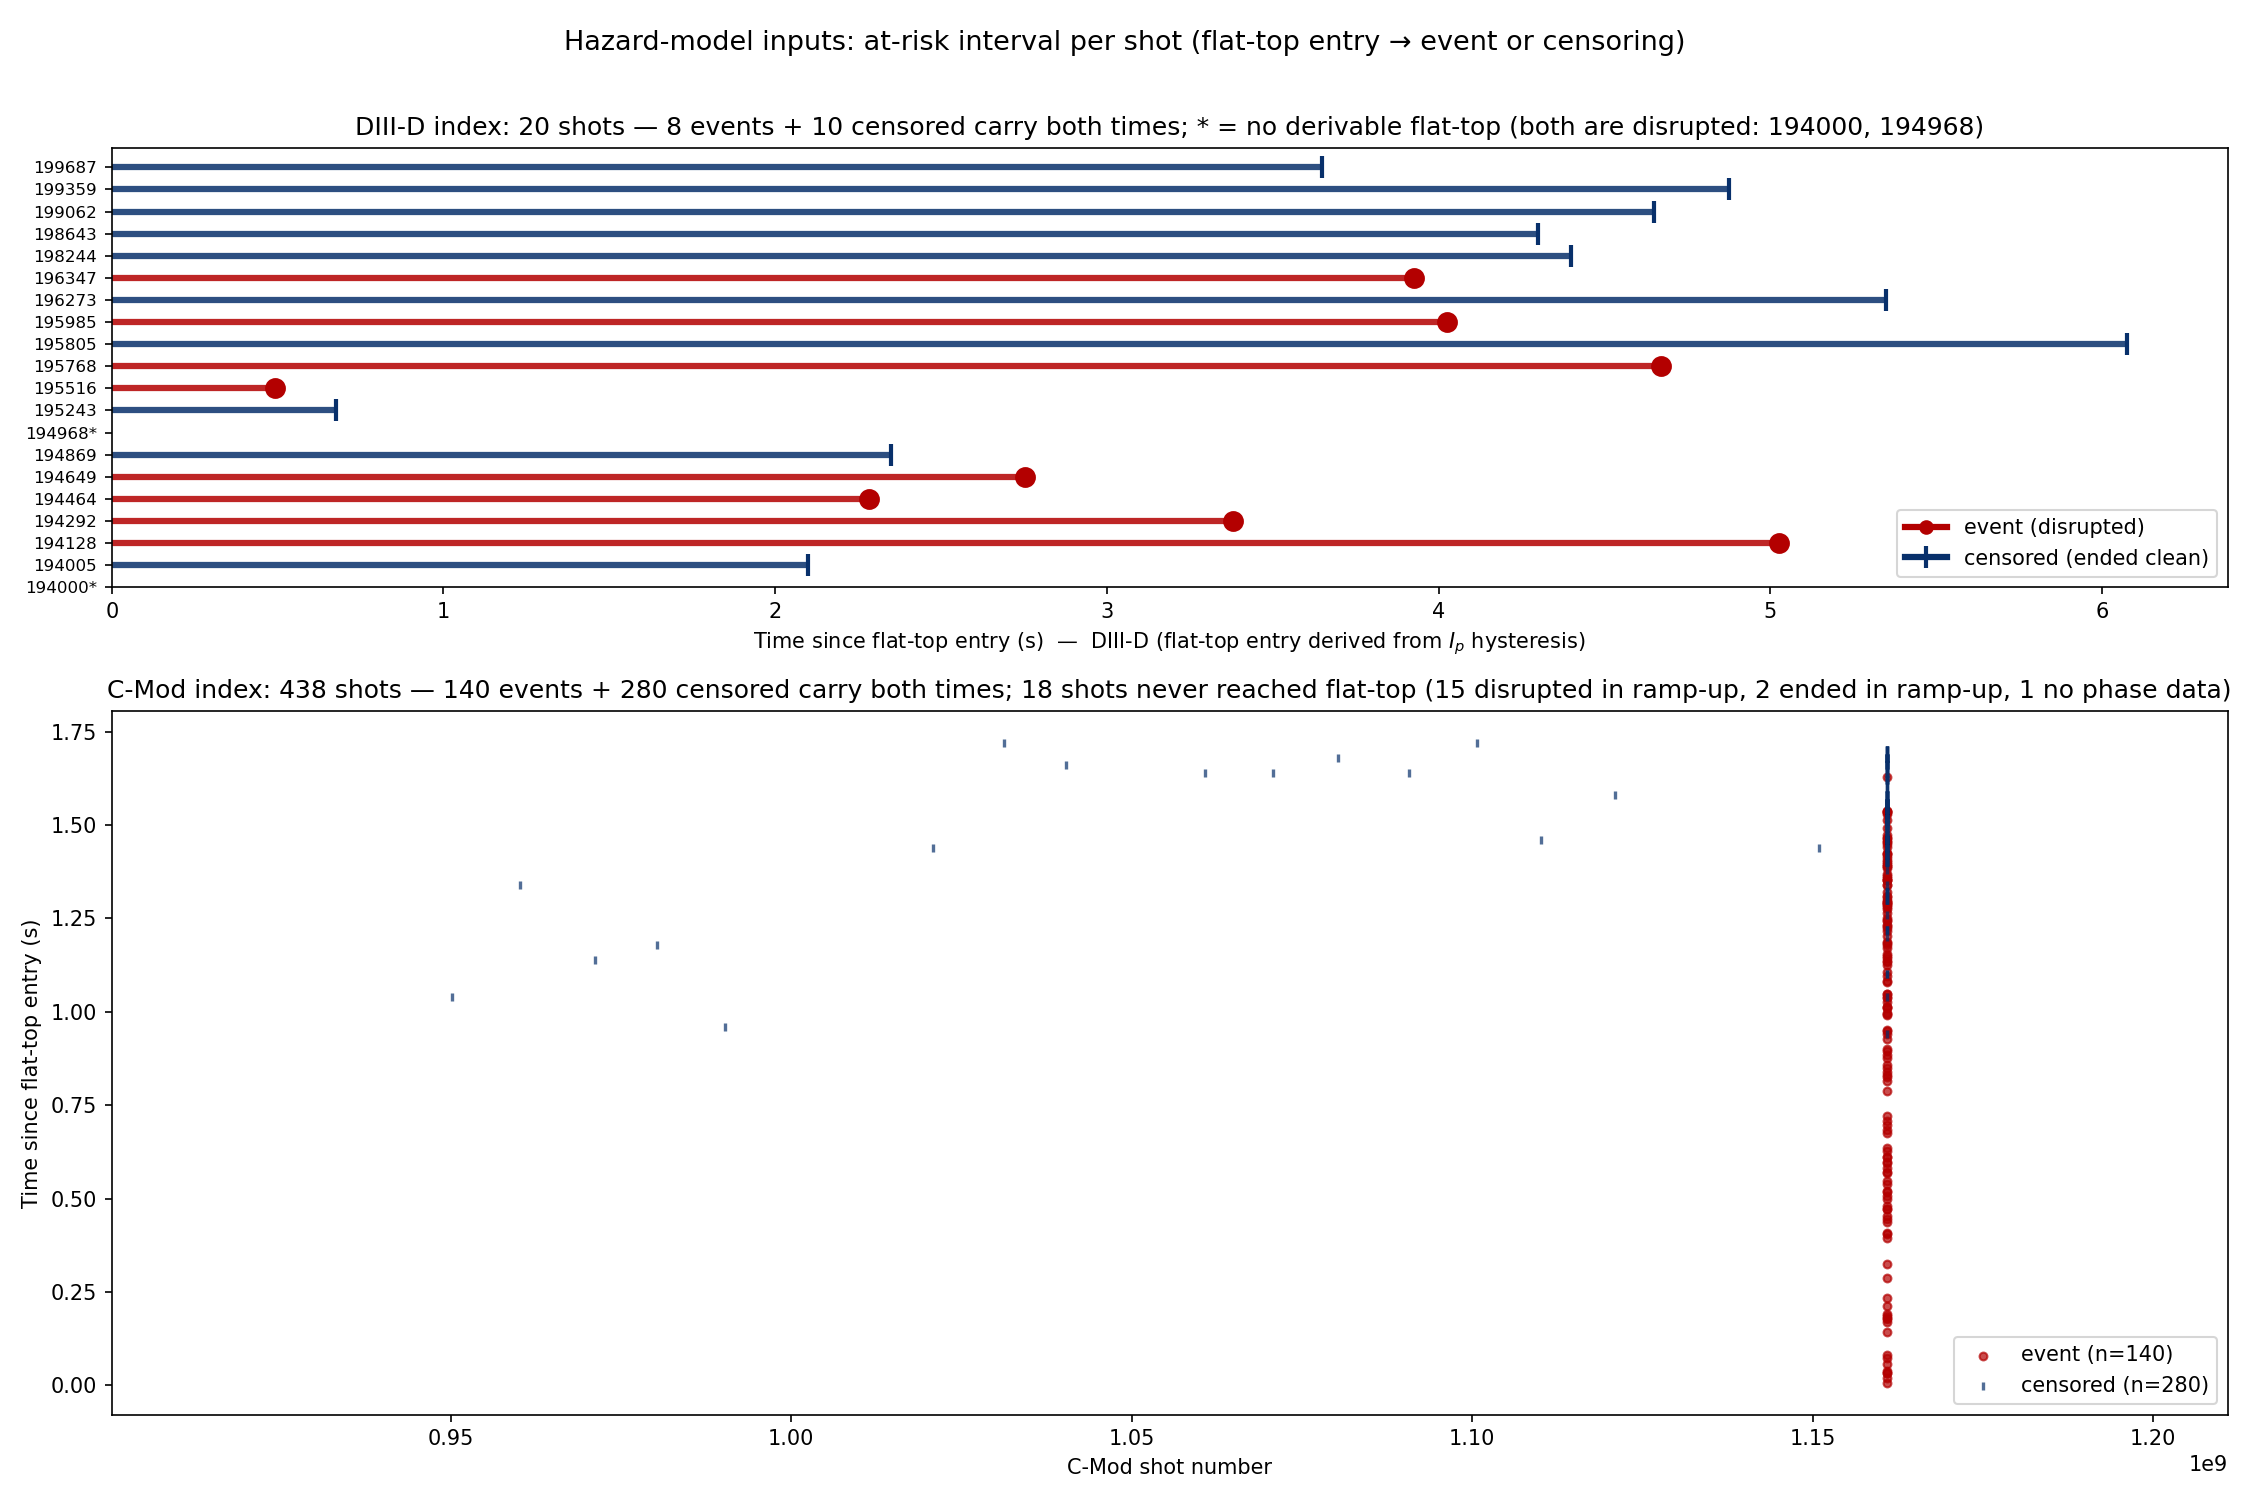

## DIII-D index (disruption-py 0.15.0.dev0 @ `9987784e…`, 20-shot constructed slice)

**Event/censoring time — present, natively.** The curated label gives `t_disrupt` for the 10 disrupted shots; for the other 10 the censoring time is the shot's last sample (`t_max` from the shot summary). Verified: every disrupted shot's last sample sits exactly at its `t_disrupt`.

**Flat-top entry — NOT present.** The only phase column, `time_domain` ("1 ramp-up, 2 flat-top, 3 ramp-down"), is blocked as unusable: it is constant 1.0 on every row because its flat-top test compares the MA-scaled `ip_prog` against a 100 kA threshold and never fires. So the index cannot tell you when flat-top began. What I gave you instead is **derived, not ingested** : flat-top entry from $I_p$ hysteresis (arm at 90% of the shot's 98th-percentile $|I_p|$, hold at 85%, 0.2 s persistence) — the anchor that handles this slice's triangular pulses and early disruptions.

| Quantity | Source | Shots covered |
|---|---|---|
| Disruption time (event) | curated label, native | 10 |
| Censoring time (clean end) | last sample, native | 10 |
| Flat-top entry | derived from `ip`, not in the index | 18 of 20 |

**Both times: 18 of 20 shots — 8 events + 10 censored. Censored: 10.** Event durations since flat-top entry: median 3.65 s (range 0.49–5.03). Censored durations: median 4.35 s (0.68–6.08).

**Missing, plainly:** shots **194000** (disrupted at 0.830 s) and **194968** (disrupted at 1.121 s) disrupt during ramp-up and never hold a flat-top — a physics result, analyzable only if you move the time origin to ramp-start. Beyond that: the slice is 20 deliberately-chosen shots (not a rate sample), the index stops *at* the disruption so nothing after it exists, and if the model needs covariates, remember EFIT-family columns gap out at shot tails on half the slice.

## C-Mod index (`cmod_origin_shots_v2.nc`, 438 shots, 156 disrupted)

**Both times, natively.** `flattop_entry()` exists precisely for this: per shot it returns `t_flattop`, `t_event` (= `t_disrupt` for events, `t_last` when censored) and a `censored` flag, which I verified equals "not disrupted" on every row.

| Quantity | Source | Shots covered |
|---|---|---|
| Flat-top entry | native phase data | 420 of 438 |
| Disruption time (event) | native label | 156 |
| Censoring time (clean end) | native | 282 |

**Both times: 420 of 438 shots — 140 events + 280 censored. Censored: 282** (the 280 with flat-top plus 2 that never reached it). Event durations: median 1.04 s (range 0.007–1.63); censored durations are tightly 0.94–1.72 s, median 1.52 — these are ~1.5 s programmed flat-tops, so censoring times are set by the pulse plan, not by random termination.

**Missing, plainly:** 18 shots have no flat-top entry — **15 disrupted during ramp-up** (their phase-1 window ends at `t_event`, within 3 ms) and **2 non-disrupted shots never left phase 1** ; these 17 are physics, not gaps. The remaining one, **931008014, has no phase data at all — a genuine data gap** . Two cautions from the pipeline's known behavior: this is a selection, not a sample of C-Mod, so hazard *rates* describe the selection only; and one flat-top disruptive shot (1160928009) carries no `time_until_disrupt` sample rows, so it silently drops out of disruption-relative window queries even though it appears in these counts.

**Bottom line:** for a hazard model, C-Mod is the ready-made index — 420 analyzable intervals out of 438, with the caveat that 16 disruptions happened before flat-top and need a different origin if you want them at all. DIII-D gives you the event/censoring side directly but makes you derive flat-top entry yourself (the native column is broken upstream), yielding 18 analyzable intervals out of 20 in a slice far too small and too constructed to estimate a hazard on its own — usable for prototyping the pipeline, not for population-level rates.

**Data files** (per-shot hazard inputs, both indices):
- `hazard_d3d.csv` — 20 DIII-D shots: label, `t_disrupt`, last sample, derived flat-top entry, duration, censor flag
- `hazard_cmod.csv` — 438 C-Mod shots: `t_flattop`, `t_event`, `t_last`, duration, censor flag
- Scripts: `hazard_d3d.py`, `hazard_cmod.py`, `hazard_cmod_probe.py`, `hazard_figure.py`

In [1]:
%%ask --review
I want to build a hazard model of disruptions, which needs for each shot the
time it entered flat-top and the time it disrupted or ended without disrupting.
Can the DIII-D index provide both? Can the Alcator C-Mod index? For each, give
me whichever parts it has, say how many shots carry both times and how many are
censored, and state plainly what is missing.

---
# C. Correctly refused — and the refusal is the finding

## Q17 — What fraction of a campaign disrupted?

_rate · **correctly refused**_

Two independent blockers: the index is a constructed slice rather than a
sample, and GA's question excludes *intentional* disruptions, which nothing in
the data flags.

In [8]:
%%ask --review
What fraction of DIII-D shots in the 2023–2024 campaigns disrupted,
excluding intentional disruptions?

I'll plan this archive-wide rate question, which needs the relational DB rather than the 20-shot index.

Reading the relational DB skill instructions first.

Reading the last few lines of the skill file.

Checking prior scripts and their recorded findings before querying fresh.

Reading the earlier schema-listing script to reuse its table-enumeration approach.

...

The BRIEF query needs `RUN` since `time_of_shot` lives in SUMMARIES — fixing and re-running.

The probe results are conclusive. Before reporting, I'm recording the SQL-dialect lessons from this session's edit-and-retry cycles in the skill's Learnings file.

Reading the earlier index-query script to reuse its exact API pattern for the composition recount.

Now recomputing the index label composition directly, so any figure I state is traceable to a query run in this session.

## Answer: this fraction cannot be computed from the data available in this environment — and I'd rather say that plainly than hand you a number that looks like one.

Here is everything the question decomposes into, and what I found for each part.

**The denominator exists.** The DIII-D shot records cover the 2023–2024 campaigns well: **5,055 plasma shots** fall in the window by shot timestamp (2,278 in 2023, 2,777 in 2024; the session-date field agrees at 2,279 + 2,777), spanning shot numbers 193503–202230. Timestamps are populated for the whole window, so the denominator is solid.

**The numerator does not exist here.** Every candidate source for "which of those 5,055 disrupted" fails:

- **The authoritative label store** — the disruption index built from disruption-py — covers only **20 shots** , all inside your window (2023-01-23 to 2024-07-22). Its label composition, which I queried directly, is **10 disrupted and 10 non-disrupted** , and the index's own metadata flags it `is_representative_sample: False`. So the 50% you would read off those 20 shots is a property of how the index slice was assembled, not of the campaigns — it cannot be scaled up to the 5,055.
- **The dedicated disruption-label tables** from the original database are legacy and deliberately excluded from the snapshot served here (per GA, do not use).
- **The shot-summary disruption scalars** are empty for this entire window — disruption time filled on 0 of 5,055 shots — and even where populated they are explicitly not a verified label source.
- **Fault codes** are blank for all 5,055 shots in the window.

**The intent exclusion cannot be applied at all.** There is no field anywhere in this snapshot that distinguishes an intentional disruption (a deliberately triggered shot, e.g. for mitigation studies) from an unintentional one. The shot-quality flag is NULL on every row; the shot-type categories carry no intent meaning (23,328 are simply "unknown"); and a free-text search of the operator descriptions for "disrupt" returns zero hits in the window. So even with a numerator, this dataset could not separate the two populations.

## What it would take

A real answer needs disruption-py (or GA's disruption-pipeline labels) run across the full 2023–2024 shot set, plus GA's classification of intentional disruptions. Neither is served in this environment; the honest statement is that the fraction is **not computable here** , not that it is low or high.

The query scripts are saved as `campaign_disrupt_probe.py`, `campaign_disrupt_denominator.py`, and `campaign_index_composition.py` in the working directory.

---
# D. What a second device makes askable

## Q18 — Which discharge phase was each disruption in?

_phase · **native on C-Mod, derivable only on DIII-D**_

The DIII-D index carries a column meant for exactly this, and it does not work.
The C-Mod index resolves the phase for nearly every disrupted shot. Same
question, same pipeline, two machines — and only one of them answers from what
it holds. Which half of that is a fact about the plasma and which is a fact
about the recording is the thing worth knowing.

I'll plan this two-index phase audit, then refresh both skills' documentation before writing any code.

Now the C-Mod skill and its learnings.

Reading the remaining lines of the C-Mod learnings file.

The skills are loaded and the C-Mod learnings already carry a verified decomposition I can re-derive against. Before writing code, I'll check the exact headers of the CSVs saved last turn so the new scripts join them correctly.

The documentation phase is done — now I'll compute the classifications. Marking that step in progress and writing the DIII-D phase script (native `time_domain` is unusable there, so phases must be derived from the programmed and measured plasma current).

...

The correction is to the agreement count between the two flat-top derivations — I'll recompute it from the saved CSVs rather than restate it, so the count exists in a tool result.

Wrong column name — checking the actual header of `phase_d3d.csv`.

The column is `t_flat_top_prog` — fixing and re-running.

The recomputation surfaces the real story: the stored diff for 196347 is 0.0750000476837158 s (float32 storage artifact), which falls a hair outside a strict 0.075 cut — my original "six of eight" counted that knife-edge literally while the display showed 0.075. The defensible statement is seven of eight within 0.08 s, with 195516 the sole real outlier at 0.300 s. Recording both lessons before re-issuing the report.

## Disruption phase, disrupted shot by disrupted shot

**DIII-D index** (10 disrupted shots in the 20-shot slice): **5 flat-top, 4 ramp-down, 1 ramp-up, 0 undetermined — but derived, not native.** The index's only phase column, `time_domain`, is unusable: it is constant 1.0 on every row (verified on shot 194128: one distinct value over 269 samples) because its flat-top test compares the MA-scaled `ip_prog` against a 100 kA threshold that never fires. Its caveat states: "Constant 1.0 for every row … the column carries no information." So every phase call below is my derivation from the programmed current (`ip_prog`, p98-referenced plateau with 0.3 s persistence, 90% exit band) cross-checked against measured `ip` — no DIII-D phase answer exists *from the index itself*.

**C-Mod index** (156 disrupted shots in the 438-shot selection): **54 flat-top, 86 ramp-down, 15 ramp-up, 1 undetermined** , straight from the native phase column via `phase_at_disruption` (one call per shot, batched metadata from `flattop_disruptions()`).


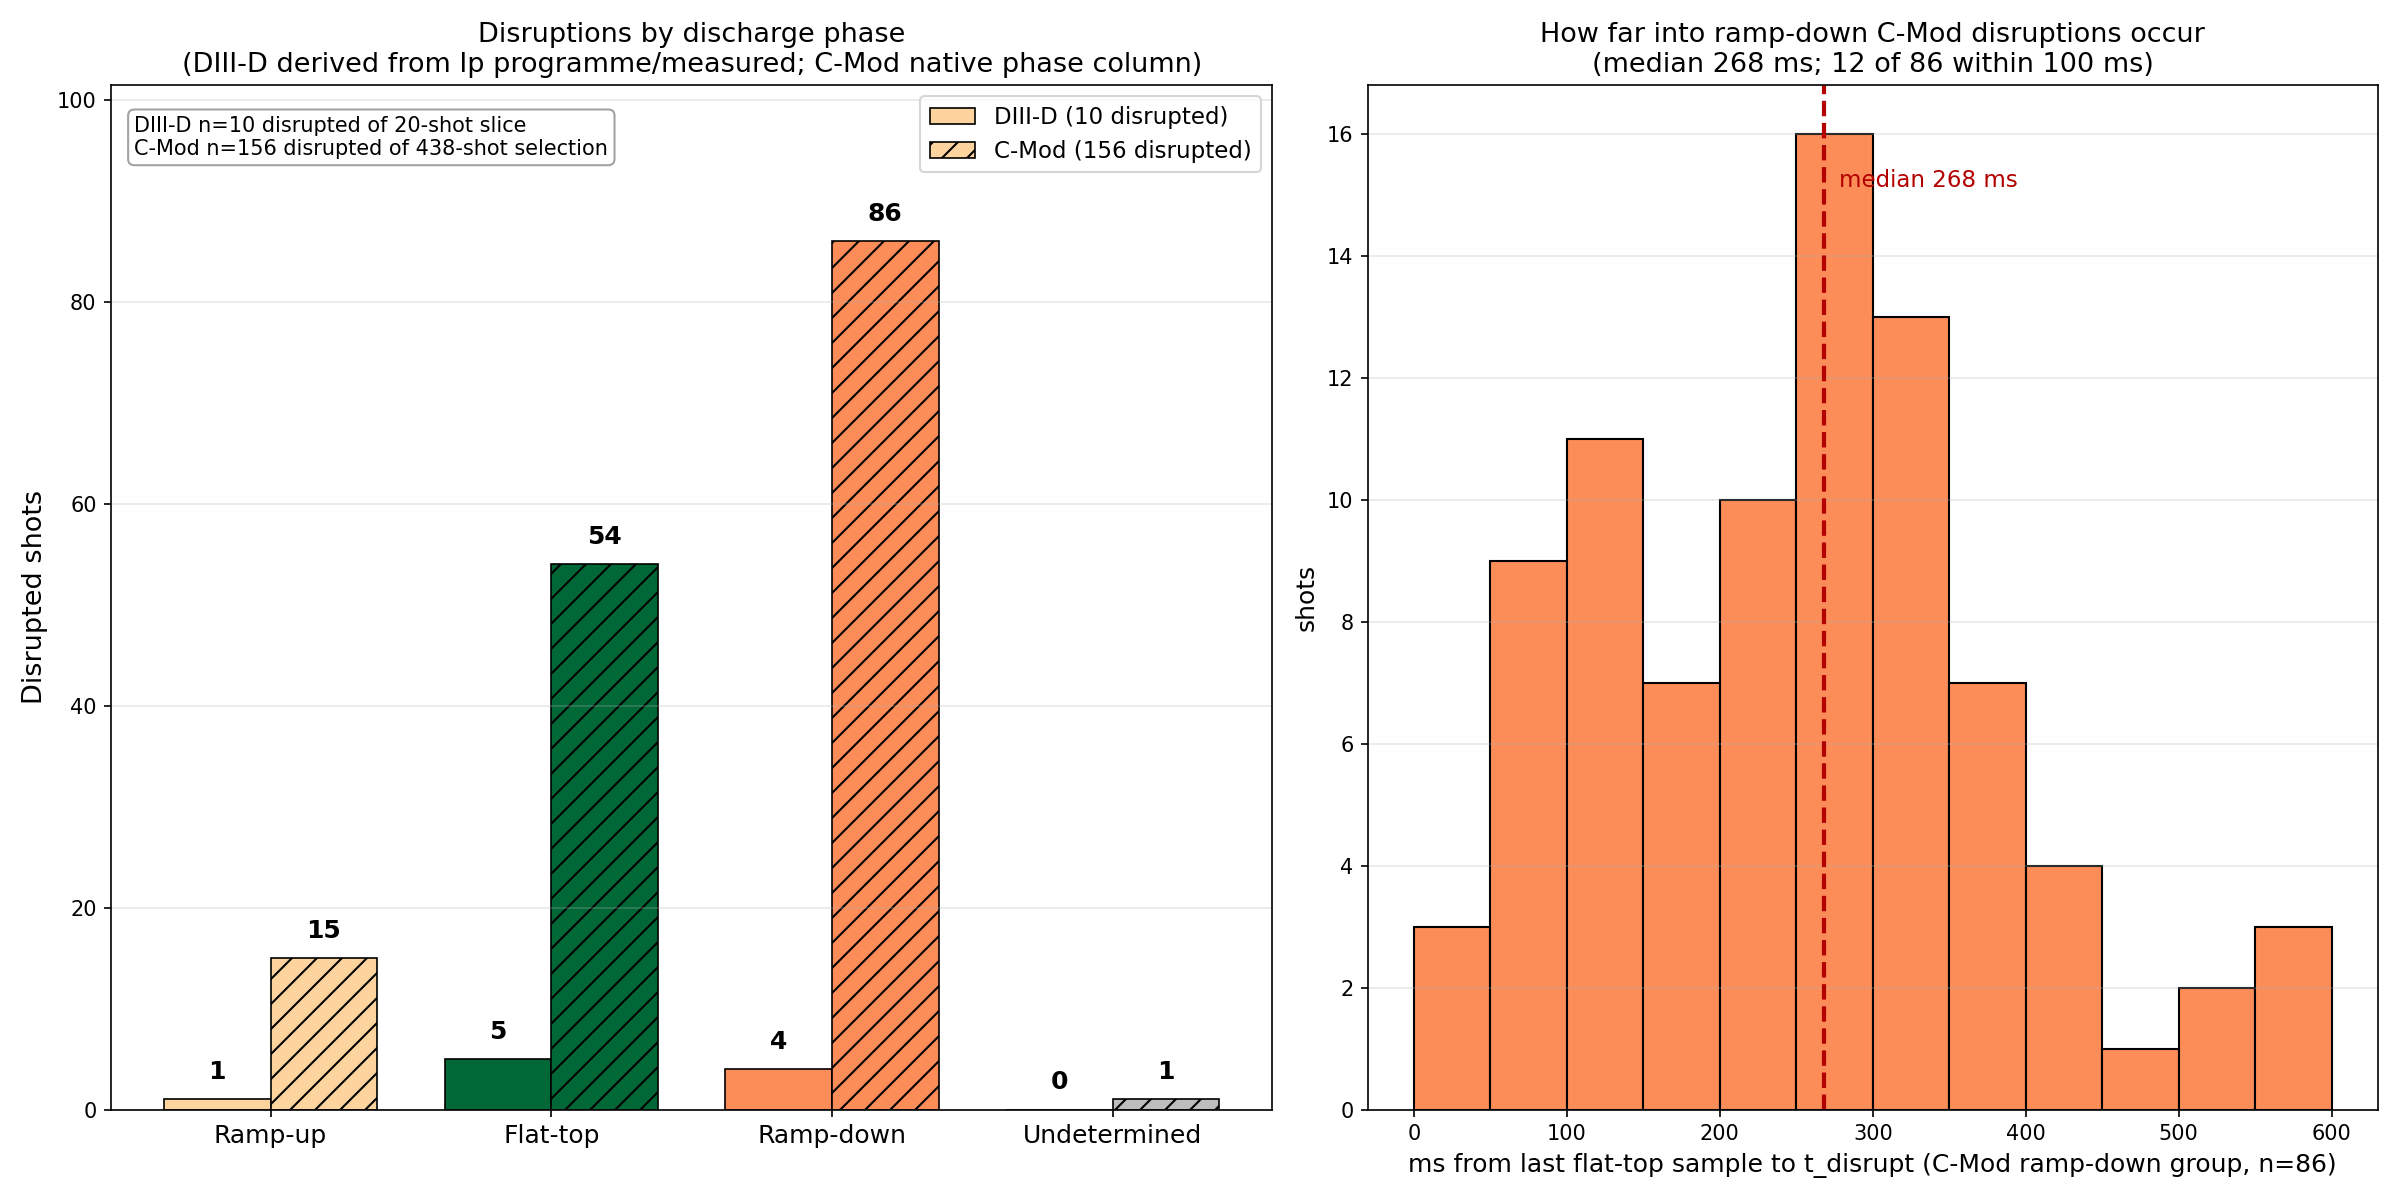

### DIII-D, shot by shot

| Shot | Phase at t_disrupt | Evidence |
|---|---|---|
| 194000 | ramp-up | programme still rising at disruption, +0.62 MA/s; no flat-top ever held (0.09 s ≥95% of p98) |
| 194128 | ramp-down | disruption 0.23 s after programme left the 90% band (4.68 s plateau before it); t_d = 5.6267 s |
| 194292 | flat-top | 1.60 MA plateau held 3.36 s to the last sample; t_d = 4.3318 s |
| 194464 | flat-top | 1.20 MA plateau held 2.28 s to the last sample; t_d = 3.1843 s |
| 194649 | flat-top | 1.60 MA plateau held 2.70 s to the last sample; t_d = 3.3521 s |
| 194968 | ramp-down | short triangular pulse, no flat-top (0.10 s); programme falling −1.82 MA/s at disruption; t_d = 1.1206 s |
| 195516 | ramp-down | short triangular pulse, no flat-top (0.08 s); programme falling −2.00 MA/s; t_d = 1.2182 s |
| 195768 | ramp-down | disruption 0.17 s after programme left the 90% band (4.32 s plateau); t_d = 5.2969 s |
| 195985 | flat-top | 1.96 MA plateau held 3.97 s to the last sample; t_d = 4.8000 s |
| 196347 | flat-top | 1.95 MA plateau held 3.85 s to the last sample; t_d = 5.4763 s |

Two things to hold onto here. First, **the measured current at the disruption instant is 14–49% of its reference on every one of these shots** — the collapse is already underway in the final samples, which is why the *programme*, not the collapsing measurement, is the only sound phase anchor. Second, this refines the earlier coarse note that 194000 and 194968 "disrupted during ramp-up": checking the programme slope shows **194968 (and 195516) were already on the descending limb** of a triangular pulse — ramp-down, not ramp-up; only 194000 is a true ramp-up disruption. As a cross-check on the anchor itself, the programme-anchored flat-top entries agree with the independently derived measured-hysteresis entries from the hazard analysis on **seven of the eight comparable shots to within 0.08 s** (per-shot diffs: 0.000, 0.000, 0.025, 0.050, 0.050, 0.050, 0.075 s), with the sole real outlier **195516 at 0.300 s** — the shot whose plateau never qualified under either derivation. No DIII-D shot is undetermined — but that is a property of my derivation, not of a native field; if you need a *native* phase call, this index cannot supply one for any shot.

### C-Mod, group by group

Of the 156 disrupted shots: **flat-top 54, ramp-down 86, ramp-up 15, undetermined 1** (counts total 156, reconciled).

- **Ramp-up (15)** : the phase-1 window ends at the disruption to within 2.90 ms (median 0.00 ms), and none of the 15 has any flat-top window — a genuine ramp-up disruption, not a boundary artifact. These plus the one undetermined shot are exactly the 16 disrupted shots that carried no flat-top entry in the hazard analysis.
- **Ramp-down (86)** : the disruption follows the last flat-top sample by a median 268 ms (p90 405 ms, max 591 ms); only 12 of 86 are within 100 ms, 3 within 50 ms, 1 within 5 ms. This group is dominated by real, established ramp-downs, but note the classifier caveat the skill documents: a disrupting shot's final milliseconds get labeled ramp-down *because the current is already collapsing*, so shots that held flat-top until the onset still land here. Under a "last flat-top sample inside a 100 ms window" criterion, 12 of these 86 would instead count as flat-top disruptions (54 → 66).
- **Flat-top (54)** : the classifier called flat-top at the disruption instant itself; none has a phase-3 window. This count uses the instant criterion, which is the conservative of the two.
- **Undetermined (1): shot 931008014** — `phase_windows()` returns an empty list for it and `phase_at_disruption()` returns None. That is a real data gap, not physics: 57 sample rows exist (t = 0.10–1.22 s, t_disrupt = 1.2208 s), but no phase column values. It is the same shot that was already flagged as the index's one no-phase-data case.

Also worth knowing: **1160928009** is classified flat-top here and does have phase windows, but it carries zero `time_until_disrupt` rows — so it appears in these counts yet silently drops out of any disruption-relative window query.

**What is missing, plainly.** DIII-D: a usable native phase column — every phase above rests on a derivation from `ip_prog`/`ip`, and `time_domain` gives nothing for any shot. C-Mod: phase data for exactly one shot (931008014). Both indices are constructed selections (DIII-D 20 shots, C-Mod 438), so these are distributions *within the selection*, not C-Mod or DIII-D disruption-phase statistics.

**Data files** (per-shot classifications and checks, both indices):
- `phase_d3d.csv` — 10 rows: phase, t_disrupt, flat-top entry, plateau length, ramp-down start, measured |ip| fraction, programme slope
- `phase_cmod.csv` — 156 rows: phase at disruption, full phase-window boundaries, ms from last flat-top sample, countdown-row count
- `phase_agreement_check.py` + its printed output — the per-shot flat-top-entry agreement diffs quoted above (programme-anchored vs measured-hysteresis, from `phase_d3d.csv` against `hazard_d3d.csv`)
- Scripts: `phase_d3d.py`, `phase_cmod_probe.py`, `phase_cmod.py`, `phase_figure.py`, `phase_agreement_check.py`

In [2]:
%%ask --review
For the disrupted shots, which phase of the discharge was each disruption in —
ramp-up, flat-top, or ramp-down? Answer for the DIII-D index and for the
Alcator C-Mod index separately, and where the phase cannot be determined, say
so and say why.

## X1 — What is the same measurement on both machines, and what only looks like it?

_cross-device · **new**_

GA's questions are written for DIII-D. With a second device carried by the same
pipeline, the prior question is which quantities mean the same thing on both
machines — and which merely share a name.

In [3]:
%%ask --review
Which disruption parameters exist for both DIII-D and Alcator C-Mod, which
exist on only one of them, and which share a name across the two without
meaning the same thing? Give the units on each machine.

This cross-machine comparison needs the full annotated parameter lists from both indices, so I'll plan, re-consult both skills, then diff them.

Both skills are in the learnings list, so I'll read their error records before writing any code.

Finishing the cmod learnings file before writing the dump script.

The learnings give me the API pitfalls (key names, batch calls, no raw-schema guessing). Now I'll write the dump script that pulls the full annotated parameter lists from both indices plus the cross-device machinery.

Running the dump script to pull both parameter inventories and the cross-device machinery.

...

The comparison ran clean — 38 pairs, 25 single-machine on each side, 10 unit-string differences. Several of those look like notation only (A/s vs A·s⁻¹, J/s vs W), so I'll pull the single-machine units and verify which differences are real scale differences before reporting.

Everything reconciles: 38 shared quantities, 25 machine-specific on each side, 3 real unit mismatches, 5 notation-only differences. One ambiguity remains — `beta_n`'s units annotations disagree ("dimensionless" vs "% m T MA⁻¹") and I can't tell from metadata alone whether that hides a real scale difference, so I'll check empirical magnitudes on both machines.

The beta_n magnitudes overlap on the two machines (0.18–1.28 vs 0.31–0.60, ratio ~1.4, not a clean scale factor), so that's an annotation inconsistency rather than a meaning difference. One last tally before the report — whether any C-Mod parameter is blocked the way three DIII-D ones are.

All checks are done — no retries were needed, so no learnings updates apply. Marking the plan complete and reporting.

## Cross-device parameter comparison: DIII-D vs Alcator C-Mod disruption indices

Both indices come from the same pipeline family — MIT's disruption-py — but each machine publishes its own parameter set. The DIII-D index (commit `9987784e…`, 20-shot slice) carries **63 parameters** ; the C-Mod index (`cmod_origin_shots_v2.nc`, 438 shots) also carries **63** . The overlap: **38 quantities exist on both** (32 under the same name, 6 renamed), and **25 exist on only one machine** — on each side. The equivalence mapping is documented from the C-Mod side only (`d3d_equivalent()` with a `mapping_source` provenance: 32 "same name in both indexes", 3 "different name, same quantity — checked against both descriptions", 3 "confirmed by the disruption-py team 2026-09-17").

### The 38 shared quantities, with units on each machine

(35 table rows — the three safety factors share one row and the two wall gaps share another.)

| C-Mod name | DIII-D name | Quantity | Units (C-Mod) | Units (DIII-D) |
|---|---|---|---|---|
| ip | ip | Measured plasma current | A | A |
| ip_prog | ip_prog | Programmed current | A | **MA — factor 10⁶** |
| ip_error | ip_error | Measured − programmed current | A | A (column blocked on DIII-D) |
| dip_dt | dip_dt | d(ip)/dt | A/s | A s⁻¹ (same) |
| dipprog_dt | dipprog_dt | d(ip_prog)/dt | A/s | **MA s⁻¹ — factor 10⁶** (blocked on DIII-D) |
| time_until_disrupt | time_until_disrupt | Label countdown | s | s |
| current_quench_time | current_quench_time | Derived quench time | s | s (DIII-D caveat: "disagrees with the label") |
| time_domain | time_domain | Phase 1/2/3 | dimensionless | "category" (blocked on DIII-D — constant 1.0) |
| v_loop | v_loop | Loop voltage | V | V |
| wmhd | wmhd | Stored energy | J | J |
| dwmhd_dt | dwmhd_dt | d(wmhd)/dt | J/s | W (J/s ≡ W — spelling only) |
| beta_n | beta_n | Normalized beta | dimensionless | "% m T MA⁻¹" — see below |
| beta_p | beta_p | Poloidal beta | 1 | 1 |
| dbetap_dt | dbetap_dt | d(beta_p)/dt | s⁻¹ | s⁻¹ (same) |
| li | li | Internal inductance | 1 | 1 |
| dli_dt | dli_dt | d(li)/dt | s⁻¹ | s⁻¹ (same) |
| q0 / q95 / qstar | same | Safety factors (axis, 95% flux, cylindrical) | 1 | 1 |
| kappa | kappa | Elongation | 1 | 1 |
| kappa_area | kappa_area | Area-based elongation | 1 | 1 |
| chisq | chisq | EFIT fit quality | 1 | 1 |
| a_minor | aminor | Minor radius | m | m |
| bt | btor | Toroidal field | T | T |
| zcur | zcur | Vertical centroid position | m | m |
| upper_gap / lower_gap | same | X-point-to-wall gaps | m | m |
| n_e | n_e | Line-averaged density | m⁻³ | m⁻³ (same) |
| dn_dt | dn_dt | d(n_e)/dt | m⁻³ s⁻¹ | m⁻³ s⁻¹ (same) |
| greenwald_fraction | greenwald_fraction | n_e / Greenwald limit | 1 | 1 |
| p_rad | p_rad | Radiated power | W | W (different diagnostics — see text) |
| radiated_fraction | radiated_fraction | p_rad / input power | 1 | 1 (DIII-D caveat: "needs clipping") |
| p_oh | p_ohm | Ohmic heating power | W | W |
| n_equal_1_mode | n_equal_1_mode | n=1 mode amplitude | T | T |
| n_equal_1_normalized | n_equal_1_normalized | n=1 / B_T | 1 | 1 |
| ne_peaking | ne_peaking_cva_rt | Density core-vs-avg peaking | 1 | 1 (team-confirmed mapping) |
| te_peaking | te_peaking_cva_rt | Temperature peaking | 1 | 1 (team-confirmed) |
| prad_peaking | prad_peaking_cva_rt | Radiation peaking | 1 | 1 (team-confirmed) |

**Same name, not the same thing — the honest shortlist:**
- **`ip_prog` and `dipprog_dt`** are the two genuine traps: **amperes on C-Mod, megaamperes on DIII-D — a factor of one million.** These are exactly the two parameters `cross_device_note()` flags, and C-Mod's `fetch_samples()` refuses them (`CrossDeviceUnitMismatch`) unless you pass `cross_device=True`. Note the internal inconsistency on the DIII-D side: `ip` is in A while `ip_prog` is in MA, and that A/MA mismatch is the root cause behind **two** of DIII-D's three blocked columns — `ip_error` collapses to a copy of `ip`, and `dipprog_dt` comes out six orders of magnitude off. The third blocked column, `time_domain`, fails for its own reason: it is constant 1.0 on every row because its flat-top threshold test never fires, so it carries no phase information at all.
- **`beta_n`** — same quantity, but the units annotations disagree outright ("dimensionless" vs the literal string "% m T MA⁻¹"). I checked empirically: whole-shot medians span 0.18–1.28 on DIII-D and 0.31–0.60 on C-Mod (6 shots each) — overlapping ranges, no clean scale factor, so this is documentation drift, not a real meaning difference. Treat both as the usual dimensionless $\beta_N$.
- **Same name, blocked on one side only:** `ip_error` (usable on C-Mod, blocked on DIII-D), `dipprog_dt` (blocked, six orders off), and `time_domain` (blocked — constant 1.0, carries no information). So these three "exist on both" only in the schema sense; on DIII-D they return plausible garbage rather than errors.
- **Six more pairs differ only in unit spelling** — `dip_dt` (A/s vs A s⁻¹), `dbetap_dt` (s⁻¹ vs s⁻¹), `dli_dt` (s⁻¹ vs s⁻¹), `dn_dt` and `n_e` (m⁻³ variants) and `dwmhd_dt` (J/s ≡ W) — **and one pair, `time_domain`, differs only in convention labeling** ("dimensionless" vs "category"). Same meanings throughout. This accounts for all ten unit-string differences the comparison found: two genuine factor-10⁶ traps, one annotation disagreement (beta_n), six spelling-only, one convention-labeling.
- Even where names and units match, "shared" means the same *quantity*, not the same instrument: `p_rad` is a 2π diode on C-Mod and smoothed bolometry on DIII-D; `n_e` comes from different line-averaging diagnostics.

### C-Mod only (25 parameters)

Vertical-stability and position-control family: `n_over_ncrit` (1), `v_z` (m/s), `z_error` (m), `z_prog` (m), `z_times_v_z` (m²/s), `i_efc` (A, error-field-correction coil current). Heating: `p_icrf` (W), `p_lh` (W, lower hybrid), `p_input` (W, ohmic+LH+ICRF). Profile diagnostics: `pressure_peaking` (1, Thomson), `te_core_vs_avg_ece` (1), `te_edge_vs_avg_ece` (1), `te_width` (m), `te_width_ece` (m), `sxr` (W, soft X-ray). Equilibrium extras: `rmagx` (m), `ssep` (m), `tribot` (1), `tritop` (1), `v_loop_efit` (V), `v_surf` (V). Derivatives/other: `dip_smoothed` (A/s), `dprad_dt` (W/s), `n_equal_1_phase` (rad), `tau_rad` (s, radiative cooling time).

### DIII-D only (25 parameters)

Heating: `p_nbi` (W, neutral beam), `p_ech` (W, electron cyclotron). Confinement/impurity: `h98` (1), `z_eff` (1), `h_alpha` (instrument units, uncalibrated). Alternative n=1 estimator: `n1rms` (T), `n1rms_normalized` (1). Shape extras: `delta` (1, triangularity), `squareness` (1), `zcur_normalized` (1), `prad_peaking_xdiv_rt` (1, divertor-region radiated-power peaking). Machine-state flag: `power_supply_railed` (0/1). And the **real-time `_rt` family — 14 parameters in all, `prad_peaking_xdiv_rt` above being the first of them; the other 13 are** : `ip_rt`, `ip_prog_rt`, `ip_error_rt` (A), `dip_dt_rt`, `dipprog_dt_rt` (A/s), `n_e_rt` (m⁻³), `dn_dt_rt` (m⁻³ s⁻¹), `greenwald_fraction_rt`, `q95_rt`, `beta_p_rt`, `li_rt`, `chisq_rt` (1), `wmhd_rt` (J) — the RT-EFIT/control-system path that C-Mod's published set doesn't include. Caution: `ip_error_rt` carries a measured 204.7× gain defect (use `ip_rt − ip_prog_rt` instead), and `dipprog_dt_rt` inherits the MA/A problem.

### Trust asymmetry worth knowing

All 63 C-Mod parameters are marked authoritative and none is blocked; 31 of 63 carry an IMAS path (the device-neutral identity — quote it when asking "what does this mean" rather than "what did C-Mod call it"). On the DIII-D side, 3 of 63 are blocked outright, one carries the gain defect above, and only 1 of 63 is flagged authoritative.

**Data files** : `xdev_parameters.csv` (master table — all 126 parameters, relation, mapping provenance, units both sides, caveats, fill), `xdev_raw_dump.json` (raw annotation dump), `xdev_beta_n_check.csv` (empirical beta_n magnitudes behind that verdict). Scripts: `xdev_dump.py`, `xdev_compare.py`, `xdev_units_check.py`, `xdev_beta_n_probe.py`.

## X2 — Do the two indexes disagree with themselves in the same way?

_cross-device · **new**_

The DIII-D index carries more than one disruption indicator, and they do not
always agree. The C-Mod index was built by the same code. Whether the same
disagreement appears there, and on how many shots, bears on whether it is a
property of the method or of the machine.

This question needs both indices' annotation layers plus fresh per-shot queries, so I'll plan it out first.

Re-reading both skill files and their learned-error records before writing any code.

Both skills are in the learnings list, so I'll read their recorded pitfalls now.

Both learnings files flag key facts: C-Mod has ~30 label disagreements and a `current_quench_time` that is bit-identical to `t_disrupt`; DIII-D's derived-vs-curated disagreements occur on curated-clean shots during ramp-down. Now I'll probe both APIs' exact return shapes before the full analysis.

Writing the probe script to learn the exact return shapes of both disagreement APIs before the full analysis.

...

Figure done. Before the report, I'll check the rest of the C-Mod learnings file and record the lessons from this session's edit-and-retry cycles.

Recording the `cmod._query` AttributeError lesson and the verified indicator-agreement facts in the C-Mod learnings file.

The heading has different leading whitespace — matching the exact text.

Both todo items done. Marking the plan complete and writing the report.

## C-Mod: yes — three indicators, and they disagree in a way DIII-D's do not

The C-Mod index (`cmod_origin_shots_v2.nc`, disruption-py 0.15.0.dev0, **438 shots: 156 labelled disrupted, 282 clean** ) carries three disruption indicators: the **per-shot label** (`disrupted` / `t_disrupt`), the **per-sample countdown** `time_until_disrupt`, and the **per-sample `current_quench_time`** . How they agree:


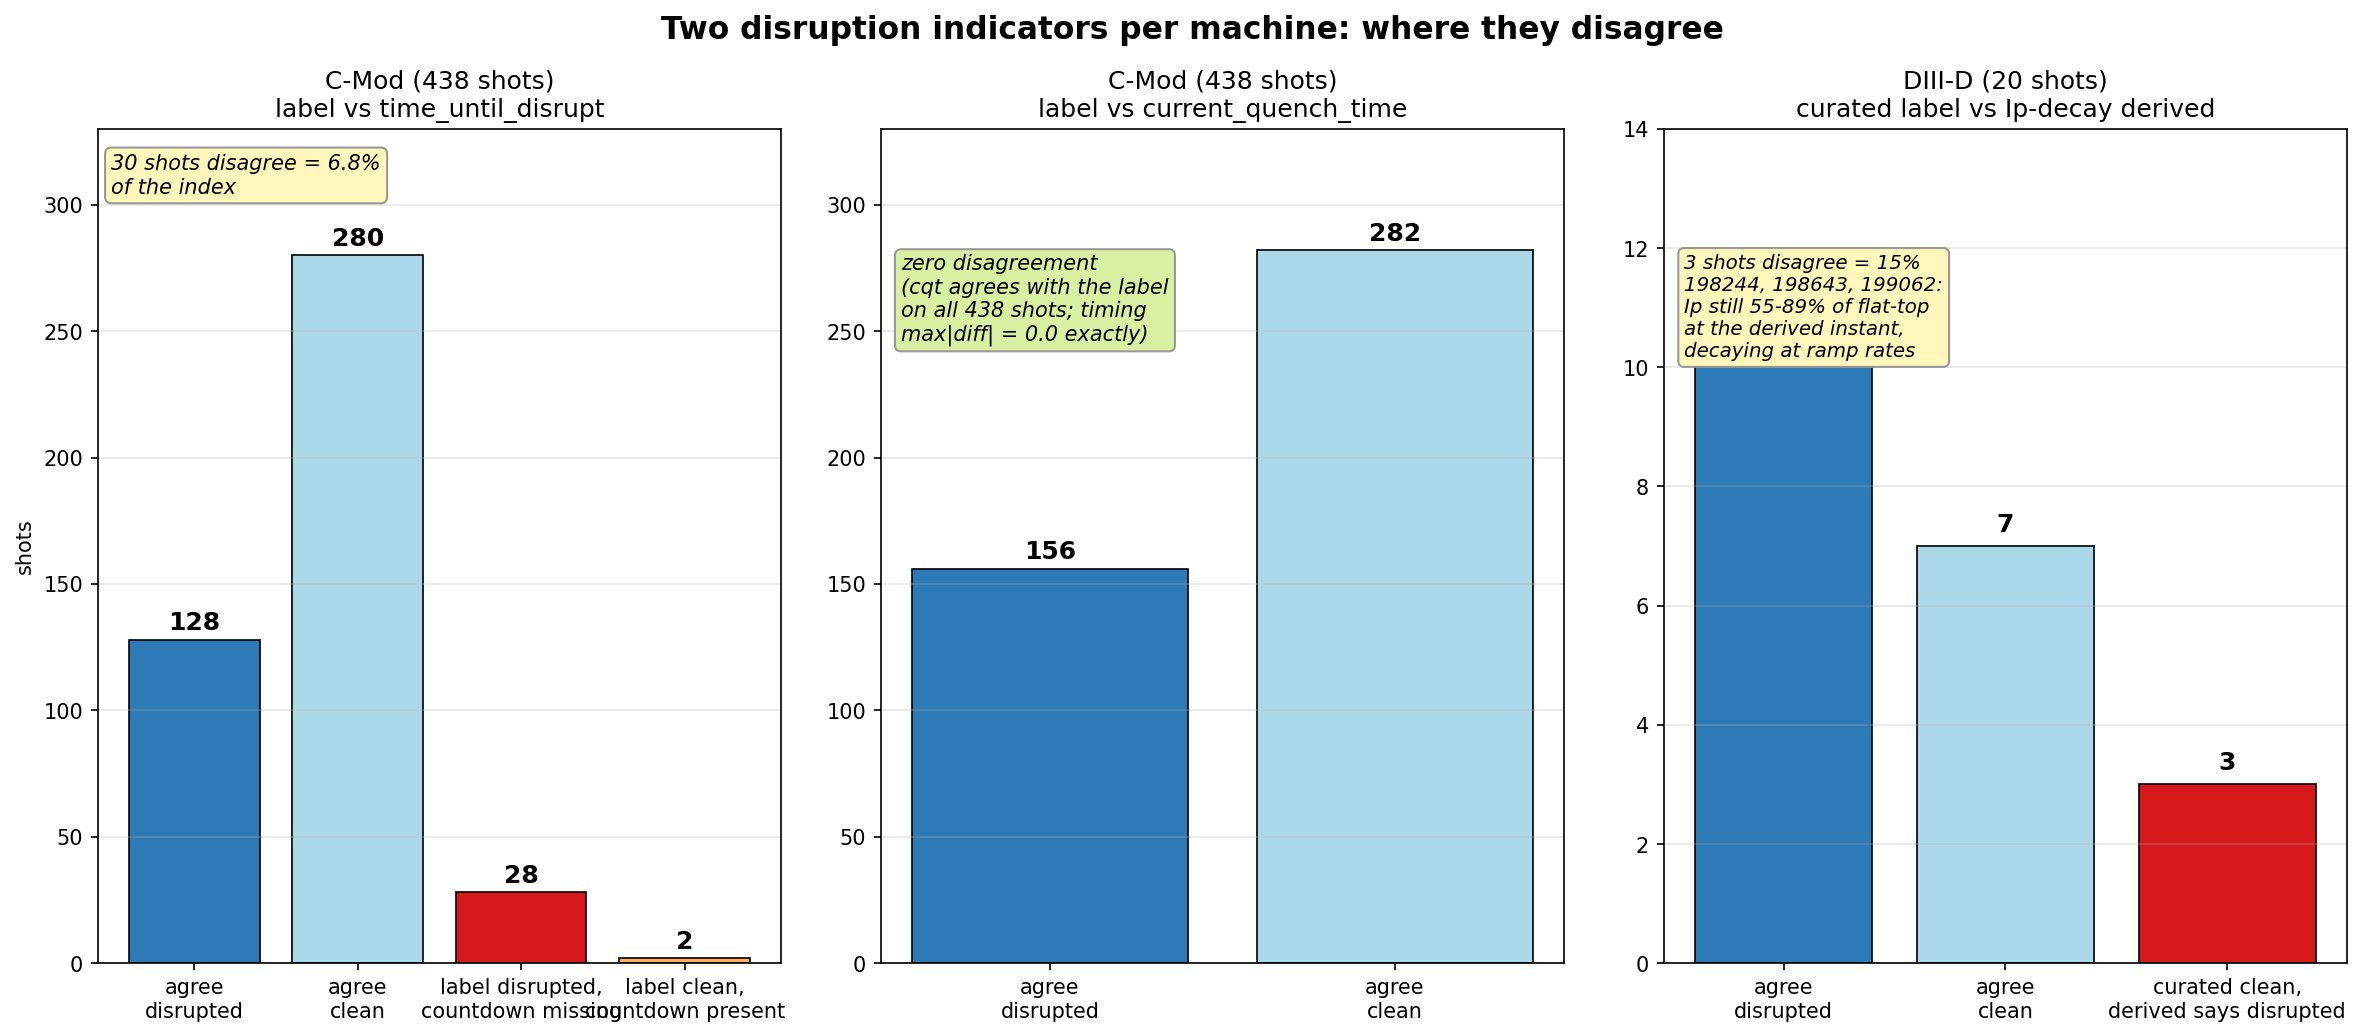

| Indicator pair | Agree | Disagree | Timing where both fire |
|---|---|---|---|
| label vs `time_until_disrupt` | 408 of 438 (93.2%) | **30 (6.8%)** | max \|Δt\| = 1.8×10⁻⁷ s over 128 shots |
| label vs `current_quench_time` | 438 of 438 (100%) | **0** | max \|Δt\| = **0.0 exactly** over 156 shots |

The 30 label-vs-countdown disagreements split by mechanism, and neither kind is a timing quarrel:

- **28 false negatives** — labelled disrupted, but `time_until_disrupt` has **zero rows** . `label_disagreements()` exists precisely to surface these. Their anatomy is diagnostic: samples run **coarse-only (20 ms) with no 1 ms burst** — the burst is present on every countdown-carrying disrupted shot (561 one-ms steps in 28 matched controls vs **0** in these 28) — and the labelled `t_disrupt` sits **0.5–16.5 ms past the last stored sample** , whereas countdown-carrying shots end exactly at `t_disrupt`. So the pipeline cut the sample table just short of the disruption and never emitted the countdown. 25 of the 28 disrupt in ramp-down, 1 in ramp-up (1160927010), 1 in flat-top (1160928009), 1 has no phase data (931008014). Practical consequence: any windowed query keyed on `time_until_disrupt` silently drops all 28 even though `current_quench_time` is filled on every one of their rows.
- **2 mirror cases** — 1160929002 and 1160929003, labelled clean, countdown present on all 23 rows each and running down to exactly 0 at the last sample. Both are ~110 ms phase-1-only discharges ending with $|I_p|$ at 33% and 50% of its peak. The indicator asserts a disruption the label denies; whether these are genuinely missed disruptions or aborted breakdown pulses is not decidable from the index.

**Do the two machines show the same kind of disagreement? No — and the difference is the finding.** DIII-D (20-shot slice, 10 curated-disrupted) compares the **curated label** (`time_until_disrupt`, d3drdb, authoritative) against disruption-py's **Ip-decay-derived** indicator (`current_quench_time`, marked non-authoritative, caveat "disagrees with the label"). They disagree on **3 of 20 shots — 198244, 198643, 199062 — every one curated-clean but derived-disrupted** (3 of the 10 clean shots; a 15% flip rate). No false negatives: all 10 curated disruptions are derived-disrupted, with timing bit-identical (max \|Δt\| = 0.0). The physics of the flips: at each derived instant $|I_p|$ is still **64%, 89% and 55%** of its flat-top reference, decaying at −0.83, −0.23 and −0.74 MA/s — programmed ramp-down rates, three orders of magnitude slower than a current quench. The estimator fires on the planned ramp-down of a clean shot.

So the disagreement kinds are opposites in direction and mechanism: **DIII-D's is a classification flip** — derived indicator false-positives on curated-clean shots, because the estimator cannot distinguish ramp-down from quench. **C-Mod's is a presence gap** — the label and the countdown column disagree about whether data exist, on shots the label calls disrupted; the one pair that could flip classifications (label vs `current_quench_time`) never does, on any of 438 shots. The only place the DIII-D kind surfaces on C-Mod at all is the two mirror shots above — indicator-positive, label-negative, current well above zero at the implied time — the same *direction*, but two shots against DIII-D's three, and with too little discharge behind them to call the mechanism.

One shared property is worth knowing: on both machines `current_quench_time` equals the label time **exactly** (0.0 µs difference on every co-flagged shot, both devices), so it adds no independent timing information — it is either a copy of the label (C-Mod's fills every disrupted row, including the 28 the countdown misses) or a derived number that happens to coincide (DIII-D). Wherever the two indicators both fire, quote one time, not two. Caveats on scope: the C-Mod index is the provider's published selection and the DIII-D index a constructed 20-shot slice, so these are disagreement rates *within each file*, not machine-wide rates.

**Data files** :
- `cmod_indicator_agreement.csv` — 438 rows: label, per-shot counts of `time_until_disrupt` and `current_quench_time` rows, timing deltas, phase at disruption for every labelled-disrupted shot
- `d3d_indicator_agreement.csv` — 20 rows: curated and derived labels, row counts, timing deltas, Ip state at derived instants for the three flips
- Scripts: `agreement_probe.py`, `indicator_agreement.py`, `cmod_disagree_probe.py`, `indicator_figure.py`

In [4]:
%%ask --review
Does the Alcator C-Mod index carry more than one disruption indicator, and do
they agree? Compare the pattern of disagreement with what the DIII-D index
shows, and say whether the same kind of disagreement appears on both machines.

---
# E. What would unblock the rest

## Summary

_synthesis · **answerable**_

In [1]:
%%ask --review
Summarise what these two indexes can and cannot support today. For the DIII-D
index and the Alcator C-Mod index separately: what can be established from what
each one holds natively, what can only be derived and under what caveat, and
what cannot be answered at all from either. Where the two differ, say which one
answers and why the other does not. Say also what produced each index, and what
that means for treating them as two independent sources.

I'll plan this capability audit, then re-ground it in both skills' documentation and a fresh metadata pull from both indices.



Re-reading both skills' documentation and their learnings files to ground the provenance and capability claims.



The Learnings files live under `.sage_learnings`, not in the skill folders — reading them from the correct path.



Reading the remaining lines of the C-Mod learnings file.



Both skills are re-grounded. Now I'll verify the live metadata from both indices with a fresh script — provenance, sizes, parameter counts, blocked/authoritative flags, and the refusal messages.



Running the verification script against both live indices.



The verification ran clean. Let me read the full provenance fields from the saved JSON to quote them exactly.



Reading the rest of the verification JSON for the C-Mod provenance and cross-device details.





All metadata is verified fresh from both live indices. Marking the audit complete and writing the summary.



## What these two indices can and cannot support today

Both are disruption-py outputs, but they are different kinds of artifact, and the difference drives almost everything below. The DIII-D index is a **constructed 20-shot slice** (10 disrupted / 10 clean, deliberately balanced); the C-Mod index is the **provider's published selection** of 438 shots (156 with a disruption time). Neither is a sample of its machine.

### What each holds natively

**DIII-D** (disruption-py 0.15.0.dev0, commit `9987784e…`, produced by `sammuli` on `omega06.gat.com`, 2026-08-19; 3,778 rows, shots 194000–199687):
- Per-shot curated label (`time_until_disrupt` from the d3drdb `disruptions` table) and per-shot derived label (`current_quench_time` from Ip decay) — both queryable, with `label_disagreements()` returning the 3 shots where they differ (198244, 198643, 199062).
- 63 parameters, 60 usable, **1 authoritative** ; 3 blocked outright (`ip_error`, `dipprog_dt`, `time_domain` — all symptoms of the `ip_prog`-in-MA defect), plus `ip_error_rt` usable-but-mis-scaled (204.7× gain).
- Per-shot summaries, sample windows, and the parameter dictionary (meaning, units, method, fill, caveat) — the dictionary is the only place semantics exist, since the NetCDF carries none.

**C-Mod** (disruption-py 0.15.0.dev0, release tag `v0.15`, produced by `barbour` on `mfews10`, 2026-09-16; 39,038 rows, shots 931008014–1160930043):
- Per-shot label, per-sample `time_until_disrupt` countdown, and `current_quench_time` (bit-identical to the label on all 156 disrupted shots).
- 63 parameters, **all 63 authoritative** , none blocked; 31 carry an IMAS path (device-neutral identity).
- A **working discharge-phase column** (`time_domain` / `phase_windows` / `phase_at_disruption` / `flattop_entry`), plus `ip_direction()` for current-sign handling and `window_before_disruption()` for SQL-side windowing.

### What can only be derived, and under what caveat

**DIII-D — discharge phase.** The index's only phase column, `time_domain`, is constant 1.0 on every row (its flat-top test compares MA-scaled `ip_prog` against a 100 kA threshold that never fires) and is blocked. Phase must be derived from `ip_prog`/`ip` — programme-anchored plateau detection with slope checks for no-plateau shots. Caveat: this is my derivation, not a native field; the measured current at the disruption instant is already 14–49% of reference, so the programme is the only sound anchor.

**DIII-D — pre-disruption physics.** All 60 usable parameters are queryable per shot, but EFIT-derived columns (`q95`, `wmhd`, `beta_n`, `li`, `q0`, `kappa`) are filled only where EFIT converged, and those gaps concentrate at shot end — exactly the window of interest. Caveat: count coverage per shot per window before quoting; some shots keep almost no EFIT samples at all.

**C-Mod — phase counts.** Native, but the instant criterion vs the window criterion give different answers (54 vs 66 flat-top disruptions of 156). Caveat: name the criterion and the count; a phase classifier labels a disrupting shot's final milliseconds ramp-down because the current is already collapsing.

**C-Mod — windowed statistics.** `window_before_disruption()` is native, but 28 of 156 disrupted shots have **zero** `time_until_disrupt` rows (coarse-only sampling, no 1 ms burst; `t_disrupt` sits 0.5–16.5 ms past the last sample). Caveat: any window keyed on the countdown silently drops those 28; count shots in-window, not from the phase list. `current_quench_time` is filled on every one of their rows, so it is the only per-sample indicator that covers them.

**Both — cross-device comparison.** 38 quantities exist on both machines, but `ip_prog` and `dipprog_dt` are **A on C-Mod, MA on DIII-D** — a factor of 10⁶. Caveat: `fetch_samples()` on C-Mod raises `CrossDeviceUnitMismatch` unless you pass `cross_device=True`; the DIII-D side has no such guard, so the trap is silent there.

### What cannot be answered at all from either

- **Archive-wide disruption rates or fractions.** Both `disruption_rate()` calls raise `PopulationClaimUnsupported` — DIII-D's slice is deliberately balanced (10/20), C-Mod's selection is the provider's published subset with no recorded selection rule. Neither says anything about how often its machine disrupts. This is the single most important limitation, and both skills enforce it by raising rather than returning a number.
- **Intent classification** (intentional vs unintentional disruptions) — no field on either machine.
- **The quench itself.** Both indices stop at `t_disrupt`; the thermal quench (~0.1–1 ms) and current quench (~1–10 ms) happen after the last sample and are outside the data. "Energy quench" is not a term in either sense.
- **C-Mod: anything needing the rest of the lakehouse.** There is no C-Mod shot catalogue, no summaries, no ELM labels — nothing joins a C-Mod shot to anything else. A question needing plasma conditions around a C-Mod shot cannot be answered here.
- **DIII-D: a native phase call for any shot** — the index cannot supply one; only the derivation above exists.

### Where the two differ, and why

| Question | DIII-D | C-Mod | Why |
|---|---|---|---|
| Discharge phase | Derived only (native column broken) | Native | `time_domain` defect is DIII-D-specific; C-Mod's phase pipeline worked |
| Parameter trust | 1/63 authoritative, 3 blocked, 1 mis-scaled | 63/63 authoritative, 0 blocked | C-Mod's file carries full annotation; DIII-D's carries almost none |
| Label provenance | Curated (d3drdb) vs derived — 3 disagreements | Label vs countdown — 30 disagreements (28 missing rows + 2 mirror) | Different label sources and different pipeline failure modes |
| Cross-device identity | No IMAS paths | 31/63 with IMAS paths | C-Mod's file was annotated with device-neutral identities; DIII-D's was not |
| Current direction | Single direction | Both directions — needs `ip_direction()` | C-Mod ran both signs; DIII-D's slice did not |

### What produced each, and what that means for independence

Both come from **the same package** — MIT-PSFC disruption-py, version 0.15.0.dev0 — but from **different producers, machines, and dates** : DIII-D by `sammuli` on `omega06.gat.com` (2026-08-19, commit `9987784e…`), C-Mod by `barbour` on `mfews10` (2026-09-16, release tag `v0.15`). They are **not two independent sources** in the sense of two independent measurements of the same thing: they share the same pipeline, the same parameter definitions, the same derived-quantity logic, and the same underlying defect class (the `ip_prog` unit error appears on both, though it only breaks DIII-D's columns). What is independent is the **input data** — different machines, different diagnostics, different shot sets — and the **label provenance** : DIII-D's label comes from a human-curated database table, C-Mod's from the provider's published disruption times. So treat them as two applications of one pipeline to two machines, not as two corroborating sources. A cross-device agreement is evidence about the pipeline's consistency, not about the physics being independently confirmed.

**Data files** : `capability_verify.json` (full provenance, sizes, parameter counts, blocked/authoritative flags, caveats, refusal messages, label-disagreement lists for both indices). Script: `capability_verify.py`.